# Proyecto: Clasificación con Naive Bayes

Este notebook implementa un clasificador **Naive Bayes** para predecir enfermedades del corazón, comparando su desempeño con otros modelos.


# 1. Importación de librerías

In [2]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [3]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc
)

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


# 2. Contexto del Minipriyecto y Análisis Exploratorio

Las enfermedades cardiovasculares son la principal causa de muerte en todo el mundo, según la OMS. Detectarlas a tiempo es fundamental para evitar complicaciones graves. Con la digitalización de los historiales médicos y la disponibilidad de datos clínicos estructurados, ahora es posible utilizar técnicas de aprendizaje automático para predecir el riesgo de falla cardíaca.
El dataset “Heart Failure Prediction” contiene registros clínicos de pacientes, con variables como presión sanguínea, colesterol, glucosa, edad, entre otras. El objetivo es construir un modelo de clasificación binaria que prediga si un paciente está en riesgo de sufrir una falla cardíaca o no (HeartDisease = 1 o 0).

Con el objetivo de mejorar la comprensión y manipulación de los datos, se decidió realizar un renombramiento de las variables. Esta medida busca estandarizar la nomenclatura, facilitar la interpretación de los datos y optimizar su tratamiento en las etapas posteriores del análisis.

In [4]:
heart_disease = fetch_ucirepo(id=45) 

x = heart_disease.data.features 
y = heart_disease.data.targets 
  
frames = [x, y]
all_data = pd.concat(
    [x.reset_index(drop=True), y.reset_index(drop=True)],
    axis=1,
    join='inner'     # asegura intersección de índices
)

# Renombrar columnas a español
all_data = all_data.rename(columns={
    "age": "edad",
    "sex": "sexo",
    "cp": "dolor_pecho",
    "trestbps": "presion_reposo",
    "chol": "colesterol",
    "fbs": "azucar_ayunas",
    "restecg": "ecg_reposo",
    "thalach": "freq_cardiaca_max",
    "exang": "angina_ejercicio",
    "oldpeak": "depresion_st",
    "slope": "pendiente_st",
    "ca": "vasos_coloreados",
    "thal": "talio",
    "num": "enfermedad_cardiaca"
})

print('All data shape: ', all_data.shape)
all_data.head()

All data shape:  (303, 14)


,edad,sexo,dolor_pecho,presion_reposo,colesterol,azucar_ayunas,ecg_reposo,freq_cardiaca_max,angina_ejercicio,depresion_st,pendiente_st,vasos_coloreados,talio,enfermedad_cardiaca
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [5]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   edad                 303 non-null    int64  
 1   sexo                 303 non-null    int64  
 2   dolor_pecho          303 non-null    int64  
 3   presion_reposo       303 non-null    int64  
 4   colesterol           303 non-null    int64  
 5   azucar_ayunas        303 non-null    int64  
 6   ecg_reposo           303 non-null    int64  
 7   freq_cardiaca_max    303 non-null    int64  
 8   angina_ejercicio     303 non-null    int64  
 9   depresion_st         303 non-null    float64
 10  pendiente_st         303 non-null    int64  
 11  vasos_coloreados     299 non-null    float64
 12  talio                301 non-null    float64
 13  enfermedad_cardiaca  303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [6]:
all_data.describe()

,edad,sexo,dolor_pecho,presion_reposo,colesterol,azucar_ayunas,ecg_reposo,freq_cardiaca_max,angina_ejercicio,depresion_st,pendiente_st,vasos_coloreados,talio,enfermedad_cardiaca
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


## 2.1 Diccionario de variables

## Variables Numéricas

| Variable            | Descripción                                                       | Unidades / Rango |
|---------------------|-------------------------------------------------------------------|------------------|
| **edad**            | Edad del paciente                                                 | años             |
| **presion_reposo**  | Presión arterial en reposo                                        | mm Hg            |
| **colesterol**      | Colesterol sérico                                                 | mg/dl            |
| **freq_cardiaca_max** | Frecuencia cardíaca máxima alcanzada                             | —                |
| **depresion_st**    | Depresión del segmento ST inducida por ejercicio (vs reposo)      | valor decimal    |
| **vasos_coloreados** | Número de vasos principales coloreados por fluoroscopía           | 0–3              |

---

##  Variables Categóricas

| Variable            | Descripción                                    | Categorías |
|---------------------|------------------------------------------------|------------|
| **sexo**            | Sexo del paciente                              | 1 = hombre, 0 = mujer |
| **dolor_pecho**     | Tipo de dolor en el pecho                      | 1 = angina típica, 2 = angina atípica, 3 = dolor no anginoso, 4 = asintomático |
| **azucar_ayunas**   | Azúcar en ayunas > 120 mg/dl                   | 1 = sí, 0 = no |
| **ecg_reposo**      | Resultados del electrocardiograma en reposo    | 0 = normal, 1 = anomalía ST-T, 2 = hipertrofia ventricular izquierda |
| **angina_ejercicio**| Angina inducida por ejercicio                  | 1 = sí, 0 = no |
| **pendiente_st**    | Pendiente del segmento ST en el ECG de esfuerzo | 1 = ascendente, 2 = plana, 3 = descendente |
| **talio**           | Resultado de la prueba de talio (*thalassemia*) | 3 = normal, 6 = defecto fijo, 7 = defecto reversible |

---

##  Variable Objetivo

| Variable                | Descripción                          | Categorías |
|--------------------------|--------------------------------------|------------|
| **enfermedad_cardiaca** | Diagnóstico de enfermedad cardíaca   | 0 = sano, 1–4 = distintos grados de enfermedad |


In [7]:
null_counts = all_data.isnull().sum()
null_columns = null_counts[null_counts > 0]

if not null_columns.empty:
    print("Columnas con valores nulos:")
    print(null_columns)
else:
    print("No hay valores nulos en la DataBase.")

Columnas con valores nulos:
vasos_coloreados    4
talio               2
dtype: int64


## 2.2 Tratamiento de datos faltantes

Tras analizar el dataset, se identificaron los siguientes valores faltantes:

- **vasos_coloreados** → 4 valores faltantes  
- **talio** → 2 valores faltantes  
- Todas las demás variables → 0 valores faltantes  

En total, el dataset contiene **6 valores faltantes** distribuidos únicamente en esas dos variables.


In [8]:
print("Índices con NaN en vasos_coloreados:", all_data[all_data['vasos_coloreados'].isna()].index.tolist())
print("Índices con NaN en talio:", all_data[all_data['talio'].isna()].index.tolist())

Índices con NaN en vasos_coloreados: [166, 192, 287, 302]
Índices con NaN en talio: [87, 266]


## Imputación de datos faltantes

In [9]:
all_data["vasos_coloreados"] = all_data["vasos_coloreados"].fillna(all_data["vasos_coloreados"].mode()[0])
all_data["talio"] = all_data["talio"].fillna(all_data["talio"].mode()[0])
print(all_data.isna().sum())

edad                   0
sexo                   0
dolor_pecho            0
presion_reposo         0
colesterol             0
azucar_ayunas          0
ecg_reposo             0
freq_cardiaca_max      0
angina_ejercicio       0
depresion_st           0
pendiente_st           0
vasos_coloreados       0
talio                  0
enfermedad_cardiaca    0
dtype: int64


Para las variables con datos faltantes, los cuales eran muy pocos se utilizó imputación por moda, asignando el valor más común dentro de cada columna como sustituto de los valores ausentes.

### Cambio de valores en variable objetivo
En el dataset original, enfermedad_cardiaca puede tomar valores:

0 → paciente sano

1–4 → distintos grados de enfermedad

Para objetivo de este projecto cambiemos estas variables por 0 y 1 respectivamente,

0 → **No** tiene enfermedad

1 → **Si** tiene enfermedad

In [10]:
# Convertir la variable objetivo a binaria
all_data["enfermedad_cardiaca"] = (all_data["enfermedad_cardiaca"] > 0).astype(int)

# Verificar los valores únicos
print(all_data["enfermedad_cardiaca"].value_counts())
all_data.head()

enfermedad_cardiaca
0    164
1    139
Name: count, dtype: int64


,edad,sexo,dolor_pecho,presion_reposo,colesterol,azucar_ayunas,ecg_reposo,freq_cardiaca_max,angina_ejercicio,depresion_st,pendiente_st,vasos_coloreados,talio,enfermedad_cardiaca
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


## 2.3 EDA

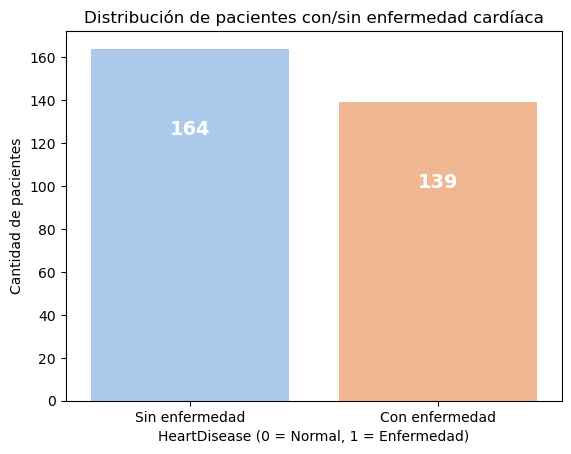

In [11]:
# 1 Distribución de pacientes con/sin enfermedad cardíaca
labels = (all_data['enfermedad_cardiaca'].value_counts())

ax = sns.countplot(x = 'enfermedad_cardiaca', data = all_data, palette="pastel")
plt.xticks(np.arange(2), ['Sin enfermedad', 'Con enfermedad'])
plt.title("Distribución de pacientes con/sin enfermedad cardíaca")
plt.xlabel("HeartDisease (0 = Normal, 1 = Enfermedad)")
plt.ylabel("Cantidad de pacientes")

for i, v in enumerate(labels):
    ax.text(i, v-40, str(v), horizontalalignment = 'center', size = 14, color = 'w', fontweight = 'bold');

In [12]:
labels

enfermedad_cardiaca
0    164
1    139
Name: count, dtype: int64

De un total de 303 personas, 164 (54.1%) están sanas y 139 (45.8%) presentan enfermedad cardíaca.
Esto refleja un ligero desbalance en las clases, aunque la diferencia no es significativa, por lo que podemos considerar que el conjunto de datos está razonablemente balanceado y resulta adecuado para el análisis predictivo.

Text(0, 0.5, 'Frecuencia')

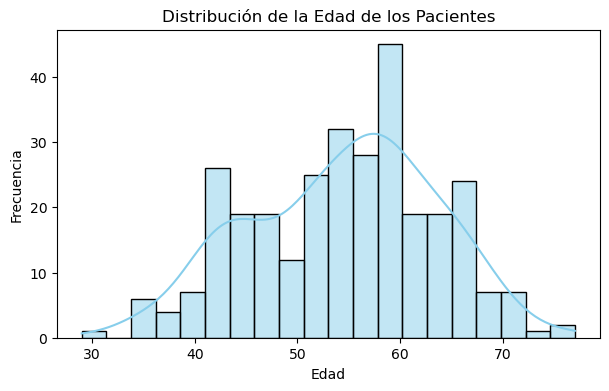

In [13]:
# 2. Distribución de la edad
plt.figure(figsize=(7,4))
sns.histplot(all_data["edad"], bins=20, kde=True, color="skyblue")
plt.title("Distribución de la Edad de los Pacientes")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")


La edad de los pacientes varía entre un rango amplio (aprox. 28 a 77 años), con una media cercana a los 55 años. La mayor concentración de casos se encuentra en edades medias y avanzadas, lo que concuerda con la literatura médica sobre mayor riesgo cardiovascular en etapas adultas.

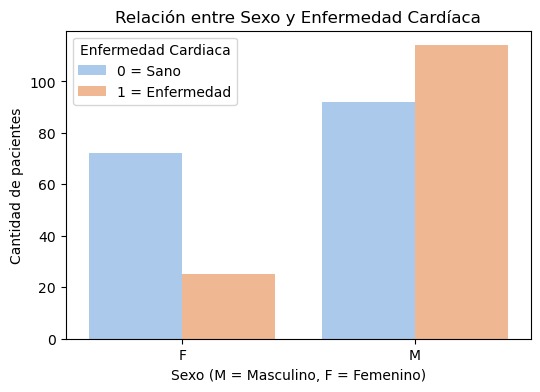

In [14]:

# 3. Relación Sexo - Enfermedad cardíaca
plt.figure(figsize=(6,4))
ax=sns.countplot(x="sexo", hue="enfermedad_cardiaca", data=all_data, palette="pastel")
ax.set_xticks([0,1])
ax.set_xticklabels(['F','M'])
plt.title("Relación entre Sexo y Enfermedad Cardíaca")
plt.xlabel("Sexo (M = Masculino, F = Femenino)")
plt.ylabel("Cantidad de pacientes")
plt.legend(title="Enfermedad Cardiaca", labels=["0 = Sano", "1 = Enfermedad"])
plt.show()

La prevalencia de la enfermedad es mayor en hombres que en mujeres, y se observa una proporción relevante de casos positivos.

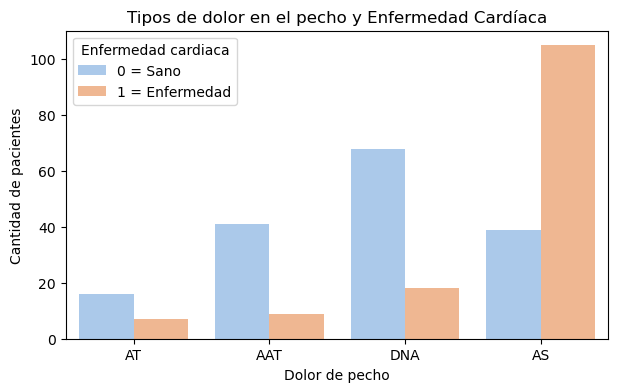

In [15]:
# 4. Tipos de dolor en el pecho (ChestPainType) vs HeartDisease
plt.figure(figsize=(7,4))
ax=sns.countplot(x="dolor_pecho", hue="enfermedad_cardiaca", data=all_data, palette="pastel")
ax.set_xticks([0,1,2,3])
ax.set_xticklabels(['AT','AAT','DNA','AS'])
plt.title("Tipos de dolor en el pecho y Enfermedad Cardíaca")
plt.xlabel("Dolor de pecho")
plt.ylabel("Cantidad de pacientes")
plt.legend(title="Enfermedad cardiaca", labels=["0 = Sano", "1 = Enfermedad"])
plt.show()

Aunque médicamente se suele asociar la presencia de síntomas con un mayor riesgo, el análisis nos revela que el grupo de pacientes asintomáticos (ASY) es el que presenta la mayor cantidad de diagnósticos positivos de enfermedad cardíaca, lo que subraya la importancia crucial de las evaluaciones preventivas incluso en ausencia de dolor en el pecho. Por el contrario, los grupos con angina atípica (ATA) y dolor no anginoso (NAP) predominan en pacientes sanos, mientras que la angina típica (TA) tiene una frecuencia general baja, lo que desafía las expectativas tradicionales y enfatiza que la falta de síntomas no descarta la presencia de la enfermedad.

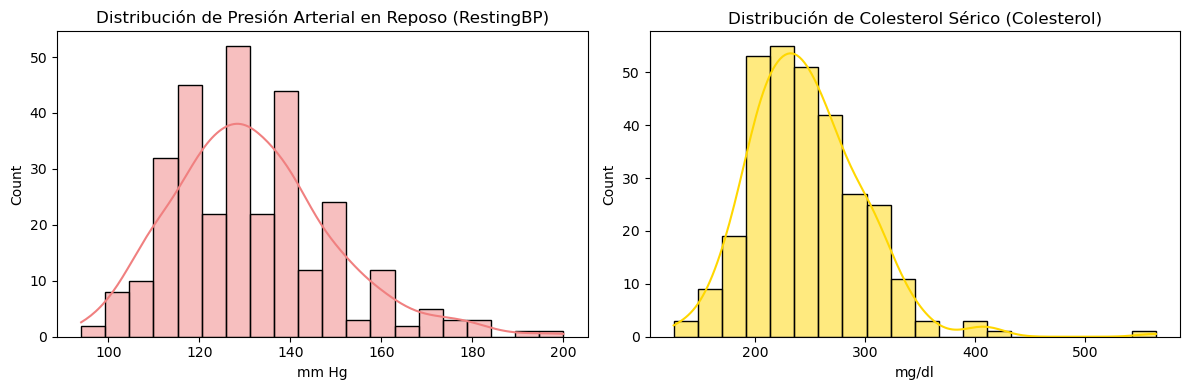

In [16]:
# 5. Presión arterial en reposo (RestingBP) y Colesterol
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.histplot(all_data["presion_reposo"], bins=20, kde=True, ax=axes[0], color="lightcoral")
axes[0].set_title("Distribución de Presión Arterial en Reposo (RestingBP)")
axes[0].set_xlabel("mm Hg")

sns.histplot(all_data["colesterol"], bins=20, kde=True, ax=axes[1], color="gold")
axes[1].set_title("Distribución de Colesterol Sérico (Colesterol)")
axes[1].set_xlabel("mg/dl")

plt.tight_layout()
plt.show()

La distribución de presión arterial en reposo (RestingBP) se concentra entre 120–140 mmHg, con forma aproximadamente normal y ligera asimetría a la derecha.

La distribución de colesterol sérico muestra asimetría positiva: la mayor densidad está alrededor de 200–250 mg/dL y se observan valores atípicos altos (≥400–500 mg/dL).

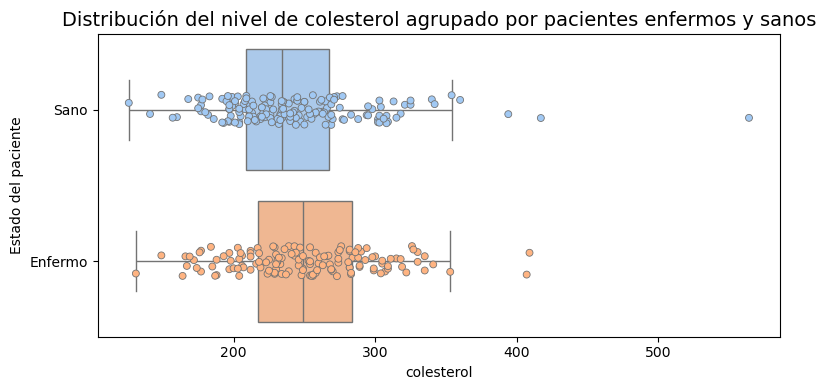

In [17]:
# 6) Distribución del nivel de colesterol
plt.figure(figsize=(8, 4))
sns.boxplot(y = 'enfermedad_cardiaca', x = 'colesterol', data = all_data, palette="pastel", fliersize = 0, orient = 'h')
sns.stripplot(y = 'enfermedad_cardiaca', x = 'colesterol', data = all_data, linewidth = 0.6, palette="pastel", orient = 'h')
plt.yticks( np.arange(2), ['Sano', 'Enfermo'])
plt.title('Distribución del nivel de colesterol agrupado por pacientes enfermos y sanos',fontsize= 14)
plt.ylabel('Estado del paciente')
plt.tight_layout()

Podemos observar que la dispersión de ambas clases con respecto al nivel de colesterol es similar , presnetando en ambos casos valores atipicos.

Es interesante ver que ese paciente que tiene nivel de colesterol muy elevado (mayor a 500) hace parte del grupo de los sanos.

Todo esto indicaria que la variable de colesterol sola no separa bien las clases, por lo que se podria asumir que el efecto no es enorme.

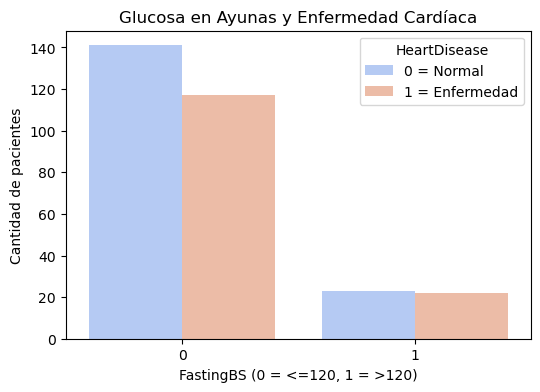

In [18]:
# 6. Glucosa en ayunas (FastingBS) vs HeartDisease
plt.figure(figsize=(6,4))
sns.countplot(x="azucar_ayunas", hue="enfermedad_cardiaca", data=all_data, palette="coolwarm")
plt.title("Glucosa en Ayunas y Enfermedad Cardíaca")
plt.xlabel("FastingBS (0 = <=120, 1 = >120)")
plt.ylabel("Cantidad de pacientes")
plt.legend(title="HeartDisease", labels=["0 = Normal", "1 = Enfermedad"])
plt.show()

La mayoría de los pacientes presenta niveles de glucosa en ayunas dentro del rango normal (≤120 mg/dl), mostrando una distribución relativamente equilibrada entre quienes padecen y no padecen enfermedad cardíaca, aunque con un ligero predominio de casos normales. Sin embargo, en el grupo con glucosa elevada (>120 mg/dl) se observa una clara y desproporcionada mayor prevalencia de diagnósticos cardíacos, lo que confirma la hiperglucemia como un significativo factor de riesgo metabólico directamente asociado a la enfermedad cardiovascular.

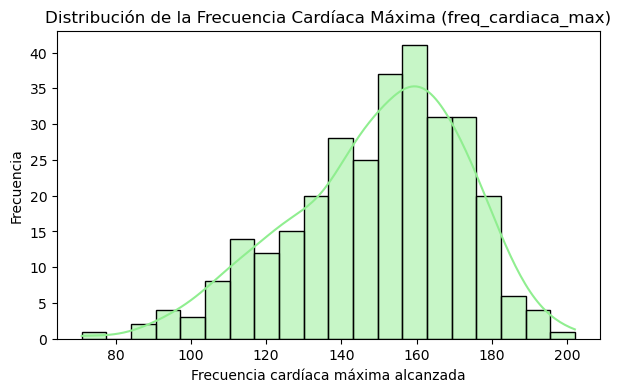

In [19]:
# 7. Frecuencia cardíaca máxima (MaxHR)
plt.figure(figsize=(7,4))
sns.histplot(all_data["freq_cardiaca_max"], bins=20, kde=True, color="lightgreen")
plt.title("Distribución de la Frecuencia Cardíaca Máxima (freq_cardiaca_max)")
plt.xlabel("Frecuencia cardíaca máxima alcanzada")
plt.ylabel("Frecuencia")
plt.show()

# 3. MODELACIÓN

In [20]:
X = all_data.drop("enfermedad_cardiaca", axis=1)  # Features
y = all_data["enfermedad_cardiaca"]               # Target

# Dividir 70% - 30%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print("Tamaño entrenamiento:", X_train.shape[0])
print("Tamaño prueba:", X_test.shape[0])

Tamaño entrenamiento: 212
Tamaño prueba: 91


Dividimos nuestro dataset en 70% training y 30% test,
quedando un tamaño para entrenamiento de 212 y de prueba de 91.

#### Matriz de Correlación

Esta primera matriz nos ayuda a ver las relaciones en los datos originales. Es útil, pero las variables categóricas (como dolor_pecho) son tratadas como números, lo que podría no reflejar su verdadera naturaleza.

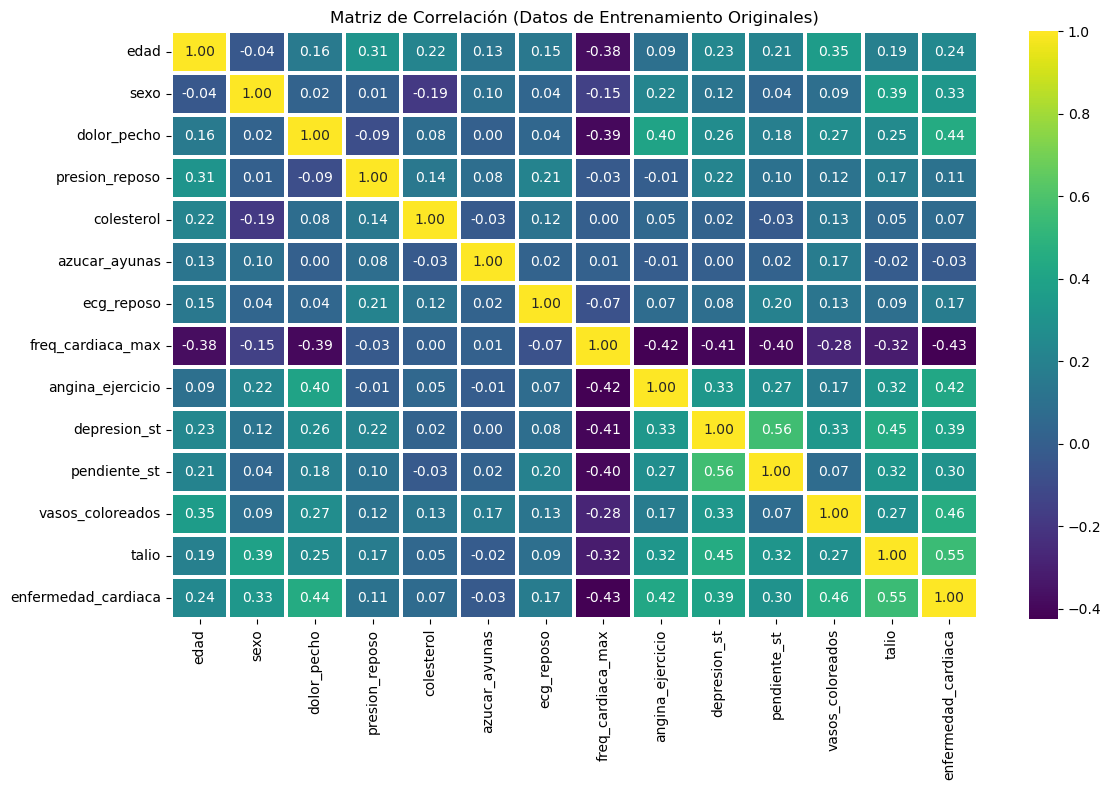

In [21]:
# Creamos una copia para no modificar el X_train original
df_train_temp = X_train.copy()
df_train_temp["enfermedad_cardiaca"] = y_train.values

# Calculamos la matriz de correlación
corr_before = df_train_temp.corr(numeric_only=True)

# Graficamos el heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_before, annot=True, linewidths=1.5, fmt=".2f", cmap='viridis')
plt.title("Matriz de Correlación (Datos de Entrenamiento Originales)")
plt.tight_layout()
plt.show()

## Pipeline de Preprocesamiento

Ahora, definimos cómo se transformarán nuestras variables. Las categóricas se convertirán usando One-Hot Encoding y las numéricas se mantendrán como están.

In [22]:
# Columnas categóricas y numéricas
cat_cols = ["sexo", "dolor_pecho", "azucar_ayunas", "ecg_reposo", 
            "angina_ejercicio", "pendiente_st", "talio"]
num_cols = [c for c in X_train.columns if c not in cat_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False, dtype=int), cat_cols)
    ],
    remainder="passthrough"
)


Esta matriz es más relevante para nuestro modelo, ya que utiliza los datos tal como los verá el clasificador después de la codificación One-Hot

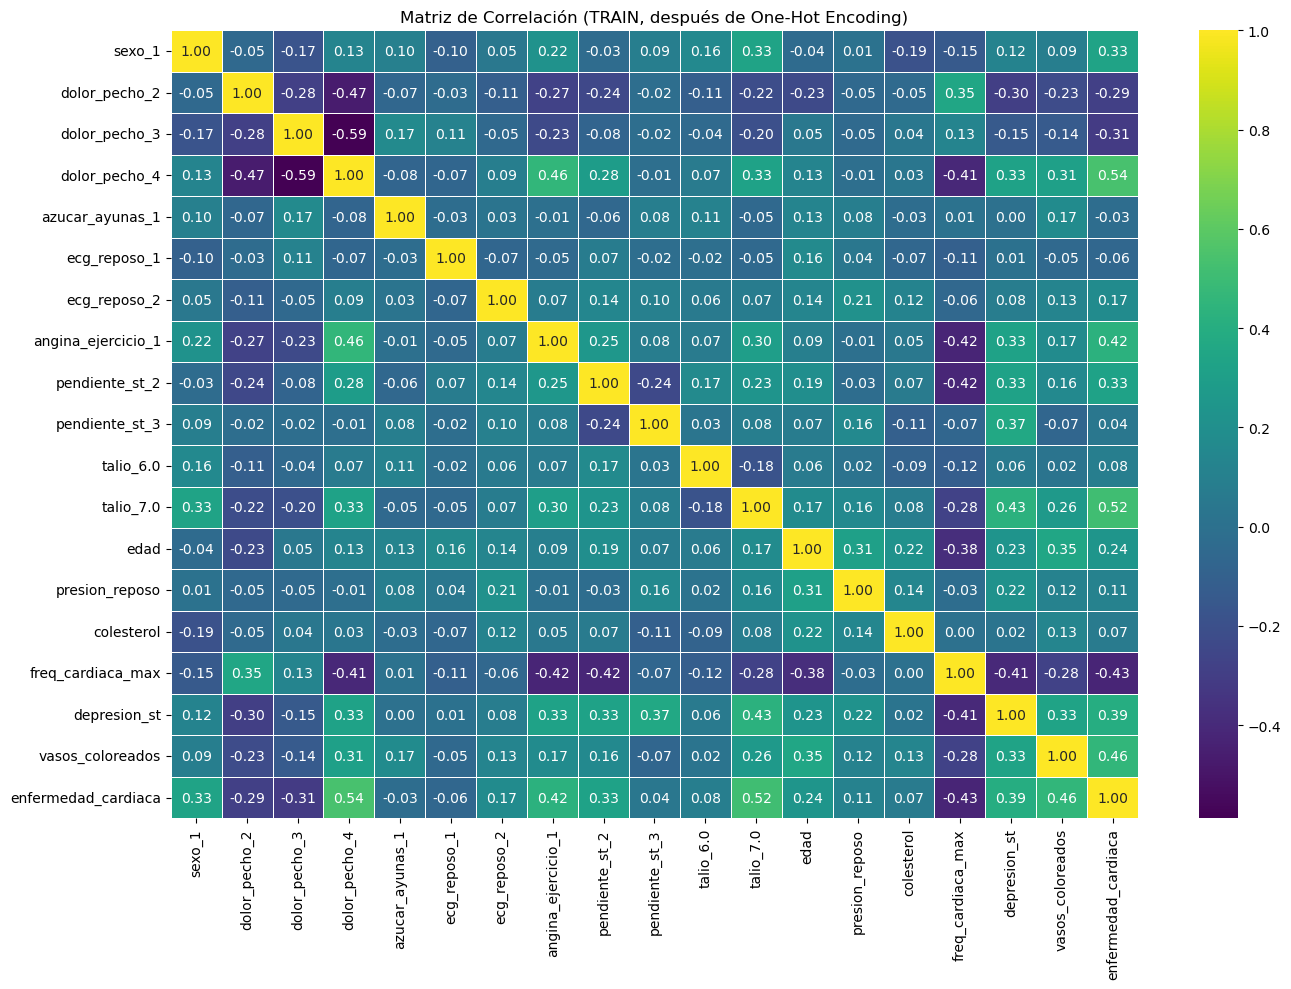

In [23]:
X_train_processed = preprocessor.fit_transform(X_train)

ohe_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)
final_feature_names = list(ohe_feature_names) + num_cols

# Creamos un DataFrame con los datos transformados y los nombres correctos
X_train_enc_df = pd.DataFrame(X_train_processed, columns=final_feature_names, index=X_train.index)

df_train_ml = X_train_enc_df.copy()
df_train_ml["enfermedad_cardiaca"] = y_train.values

corr_after = df_train_ml.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(corr_after, annot=True, linewidths=0.5, fmt=".2f", cmap='viridis')
plt.title("Matriz de Correlación (TRAIN, después de One-Hot Encoding)")
plt.tight_layout()
plt.show()

Variables más relacionadas con enfermedad_cardiaca (TRAIN, tras One-Hot)

Las variables con mayor correlación positiva con la presencia de enfermedad cardíaca son dolor_pecho_4 (asintomático) (0.54), talio_7.0 (defecto reversible) (0.52), vasos_coloreados (0.46), depresion_st (0.46) y angina_ejercicio_1 (0.43). También se observan asociaciones moderadas con pendiente_st_2 (plana) (0.35), pendiente_st_3 (descendente) (0.34), dolor_pecho_3 (no anginoso) (0.33) y dolor_pecho_2 (angina atípica) (0.25).

En cuanto a las correlaciones negativas más relevantes, destacan la frecuencia cardíaca máxima (−0.42) y el hecho de ser hombre (sexo_1) (−0.33).

## Pipeline del entrenamiento del el Modelo

In [24]:
# El pipeline aplicará el preprocesamiento y luego entrenará el modelo
clf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GaussianNB())
])

# Usamos cross_val_score para evaluar la robustez del pipeline
cv_scores = cross_val_score(clf_pipeline, X_train, y_train, cv=5, scoring='roc_auc')

print(f"Scores de AUC en validación cruzada: {cv_scores}")
print(f"AUC promedio en validación cruzada: {cv_scores.mean():.4f}")

# Entrenamos el pipeline completo con todos los datos de entrenamiento
clf_pipeline.fit(X_train, y_train)

# Hacemos predicciones en el conjunto de prueba
y_pred = clf_pipeline.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"\nAccuracy en el conjunto de prueba: {acc:.4f}")
print("\n=== Reporte de Clasificación en el Conjunto de Prueba ===")
print(classification_report(y_test, y_pred))


Scores de AUC en validación cruzada: [0.89782609 0.88695652 0.79633867 0.92677346 0.88100686]
AUC promedio en validación cruzada: 0.8778

Accuracy en el conjunto de prueba: 0.7253

=== Reporte de Clasificación en el Conjunto de Prueba ===
              precision    recall  f1-score   support

           0       0.88      0.57      0.69        49
           1       0.64      0.90      0.75        42

    accuracy                           0.73        91
   macro avg       0.76      0.74      0.72        91
weighted avg       0.77      0.73      0.72        91



c:\Users\OMAR DANIEL MEDINA V\anaconda3\envs\ml_venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:227: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


## Evaluación del Modelo en el Conjunto de Prueba

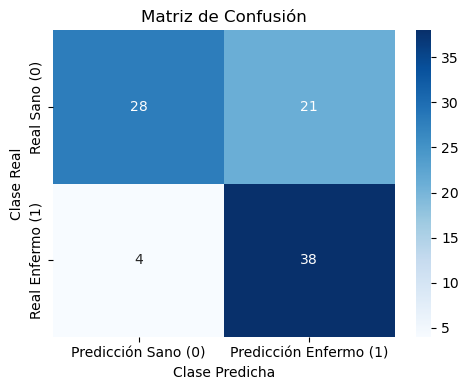

In [25]:
# Predicciones en el Conjunto de Prueba 
y_pred = clf_pipeline.predict(X_test)
y_proba = clf_pipeline.predict_proba(X_test)[:, 1]

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Predicción Sano (0)", "Predicción Enfermo (1)"],
            yticklabels=["Real Sano (0)", "Real Enfermo (1)"])
plt.title("Matriz de Confusión")
plt.xlabel("Clase Predicha")
plt.ylabel("Clase Real")
plt.tight_layout()
plt.show()


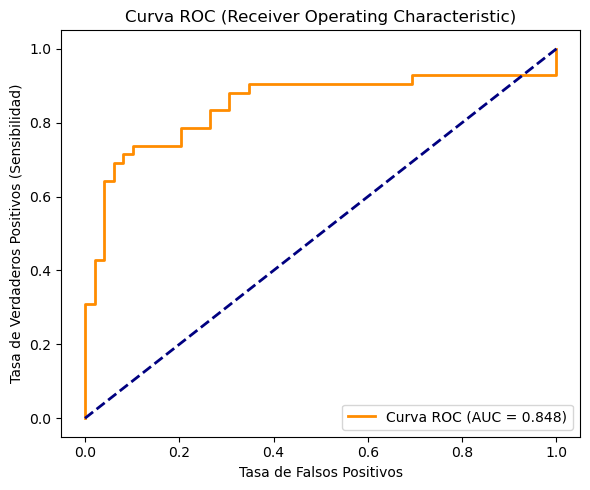

In [26]:
# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos (Sensibilidad)")
plt.title("Curva ROC (Receiver Operating Characteristic)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


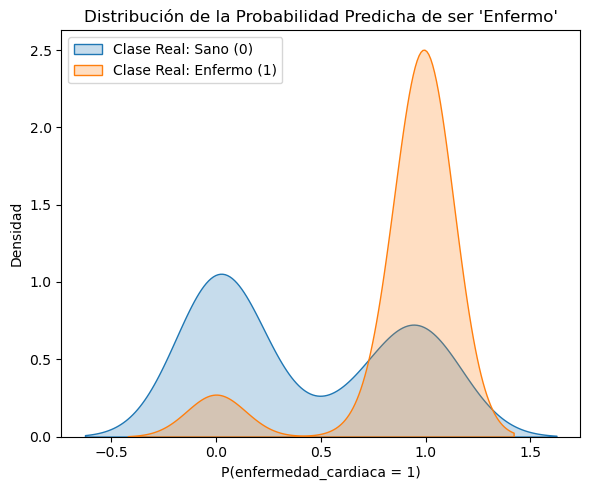

In [27]:
# Grafico de Distribución de Probabilidades
y_true_np = np.asarray(y_test)
plt.figure(figsize=(6, 5))
sns.kdeplot(y_proba[y_true_np == 0], fill=True, label="Clase Real: Sano (0)")
sns.kdeplot(y_proba[y_true_np == 1], fill=True, label="Clase Real: Enfermo (1)")
plt.title("Distribución de la Probabilidad Predicha de ser 'Enfermo'")
plt.xlabel("P(enfermedad_cardiaca = 1)")
plt.ylabel("Densidad")
plt.legend()
plt.tight_layout()
plt.show()

### Conclusiones GaussianNB

Podemos decir que el modelo muestra alta sensibilidad (90.5%), logrando identificar a la gran mayoría de pacientes enfermos (38 de 42). Sin embargo, clasifica erróneamente como enfermos a varios pacientes sanos (21 de 49) (57%). Podemos decir que se comporta como un medico “cauteloso”  que prefiere equivocarse diciendo que alguien sano podría estar enfermo, en lugar de que equivocarse diciendo que alguien enfermo está sano.

In [28]:
# Extraemos los componentes del pipeline entrenado
trained_pipeline = clf_pipeline 
nb_classifier = trained_pipeline.named_steps['classifier']
preprocessor = trained_pipeline.named_steps['preprocessor']

# Esta es una forma más directa y robusta de obtener los nombres
feature_names = preprocessor.get_feature_names_out()

# Creamos DataFrames con las medias y varianzas aprendidas por el modelo
means = pd.DataFrame(nb_classifier.theta_, columns=feature_names, 
                     index=["No Enfermedad", "Enfermedad"])

variances = pd.DataFrame(nb_classifier.var_, columns=feature_names, 
                         index=["No Enfermedad", "Enfermedad"])

print("=== Medias Estimadas por Clase y Característica ===")
display(means.T.round(3))

print("\n=== Varianzas Estimadas por Clase y Característica ===")
display(variances.T.round(3))

=== Medias Estimadas por Clase y Característica ===


,No Enfermedad,Enfermedad
cat__sexo_1,0.548,0.856
cat__dolor_pecho_2,0.287,0.062
cat__dolor_pecho_3,0.391,0.113
cat__dolor_pecho_4,0.243,0.784
cat__azucar_ayunas_1,0.130,0.113
cat__ecg_reposo_1,0.009,0.000
cat__ecg_reposo_2,0.426,0.598
cat__angina_ejercicio_1,0.139,0.536
cat__pendiente_st_2,0.313,0.639
cat__pendiente_st_3,0.052,0.072



=== Varianzas Estimadas por Clase y Característica ===


,No Enfermedad,Enfermedad
cat__sexo_1,0.248,0.124
cat__dolor_pecho_2,0.205,0.058
cat__dolor_pecho_3,0.238,0.101
cat__dolor_pecho_4,0.184,0.170
cat__azucar_ayunas_1,0.113,0.101
cat__ecg_reposo_1,0.009,0.000
cat__ecg_reposo_2,0.245,0.240
cat__angina_ejercicio_1,0.120,0.249
cat__pendiente_st_2,0.215,0.231
cat__pendiente_st_3,0.049,0.067


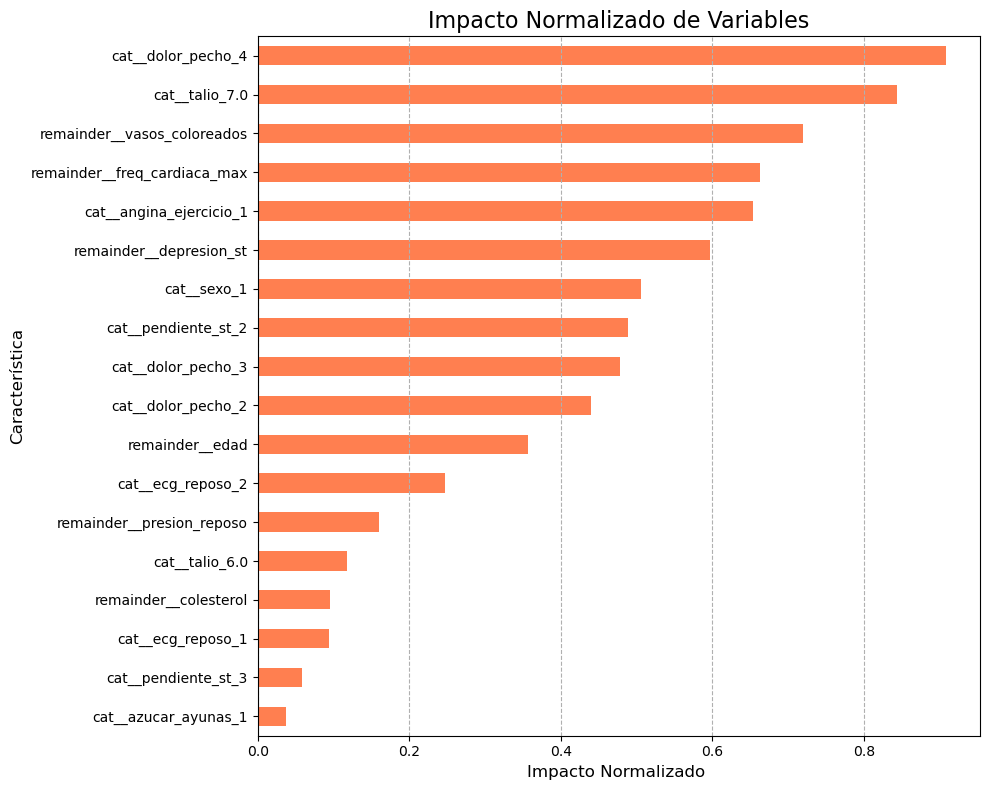

In [32]:
# Calculamos la diferencia normalizada por la varianza combinada
impacto_normalizado = ( (means.loc["Enfermedad"] - means.loc["No Enfermedad"]).abs() 
                       / np.sqrt(variances.loc["Enfermedad"] + variances.loc["No Enfermedad"] + 1e-9) ) # 1e-9 para evitar división por cero
impacto_normalizado = impacto_normalizado.sort_values(ascending=True)

# Graficamos el impacto normalizado
plt.figure(figsize=(10, 8))
impacto_normalizado.plot(kind="barh", color='coral')
plt.title("Impacto Normalizado de Variables", fontsize=16)
plt.xlabel("Impacto Normalizado ", fontsize=12)
plt.ylabel("Característica", fontsize=12)
plt.grid(axis='x', linestyle='--')
plt.tight_layout()
plt.show()

## Comparación con otros modelos

In [30]:
# Definimos los modelos a comparar 
models = {
    "GaussianNB": GaussianNB(),
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42) # n_estimators es el número de árboles
}

# Entrenamos cada modelo y guardamos sus métricas ---
results = {}

for name, clf in models.items():
    # Creamos un Pipeline para cada modelo
    model_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", clf)
    ])
    
    # Entrenamos el pipeline
    model_pipeline.fit(X_train, y_train)
    
    # Predecimos en el conjunto de prueba
    y_pred = model_pipeline.predict(X_test)
    y_proba = model_pipeline.predict_proba(X_test)[:, 1]
    
    # Guardamos las métricas
    report = classification_report(y_test, y_pred, output_dict=True)
    results[name] = {
        "Accuracy": report["accuracy"],
        "Precision (Clase 1)": report["1"]["precision"],
        "Recall (Clase 1)": report["1"]["recall"],
        "F1-Score (Clase 1)": report["1"]["f1-score"],
        "AUC": roc_auc_score(y_test, y_proba)
    }

# Mostramos los resultados en un DataFrame ---
results_df = pd.DataFrame(results).T.round(4)
print("=== Tabla Comparativa de Modelos ===")
display(results_df)

=== Tabla Comparativa de Modelos ===


,Accuracy,Precision (Clase 1),Recall (Clase 1),F1-Score (Clase 1),AUC
GaussianNB,0.7253,0.6441,0.9048,0.7525,0.8484
LogisticRegression,0.8462,0.8500,0.8095,0.8293,0.9305
KNN,0.7033,0.7143,0.5952,0.6494,0.7597
RandomForest,0.8352,0.8140,0.8333,0.8235,0.9140


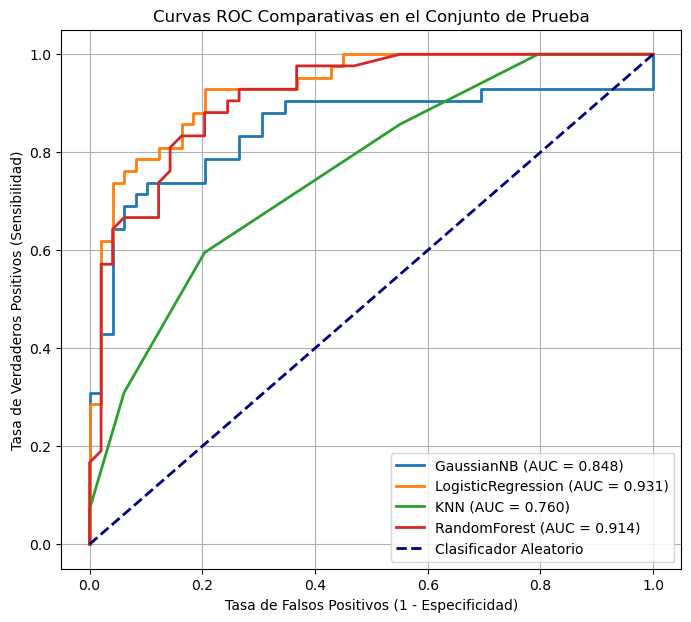

In [31]:
# Graficamos las curvas ROC de todos los modelos ---
plt.figure(figsize=(8, 7))

for name, result in results.items():
    # Entrenamos de nuevo brevemente para obtener las probabilidades para la gráfica
    model_pipeline.set_params(classifier=models[name]).fit(X_train, y_train)
    y_proba = model_pipeline.predict_proba(X_test)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc_score:.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador Aleatorio')
plt.xlabel("Tasa de Falsos Positivos (1 - Especificidad)")
plt.ylabel("Tasa de Verdaderos Positivos (Sensibilidad)")
plt.title("Curvas ROC Comparativas en el Conjunto de Prueba")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# 4. Reflexión y Conclusiones Finales

El proyecto evaluó el uso de Naive Bayes para predecir enfermedades cardíacas y lo comparó con modelos más complejos como Regresión Logística y Random Forest. Aunque estos últimos alcanzaron mejor rendimiento global (AUC > 0.91 frente a 0.85 de Naive Bayes), el modelo bayesiano destacó por su alta sensibilidad (RECALL 90.5%), lo que lo convierte en una herramienta muy eficaz para la detección temprana.

En términos clínicos, Naive Bayes minimiza los falsos negativos, priorizando no pasar por alto a pacientes enfermos, aun a costa de más falsos positivos. Esto lo hace ideal como modelo de cribado o screening inicial, donde se busca identificar a la mayoría de los pacientes en riesgo antes de pruebas más específicas.

Además, aporta interpretabilidad, manejo explícito de la incertidumbre y un buen desempeño con datos limitados. Su principal limitación es la asunción de independencia entre variables, lo que explica por qué modelos más complejos logran métricas globales superiores.

En conclusión, mientras que la Regresión Logística es la mejor opción si se busca precisión general, Naive Bayes resulta sumamente valioso cuando la prioridad es no dejar sin detectar a pacientes enfermos.